<a href="https://colab.research.google.com/github/Kamaleshdk/mnist-digit-classification/blob/main/Mnist_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist

In [ ]:
(train_images,train_labels),(test_images,test_labels) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(train_images.shape,train_labels.shape)
print(test_images.shape,test_labels.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [ ]:
Label_name = ['0','1','2','3','4','5','6','7','8','9']

In [ ]:
print(Label_name)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


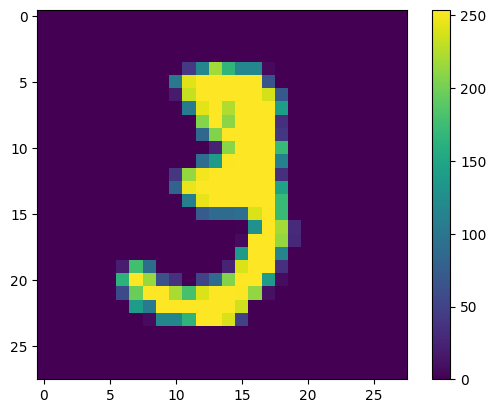

In [ ]:
plt.figure()
plt.imshow(train_images[10])
plt.colorbar()

In [ ]:
# Preprocessing


train_images = train_images/255.0
test_images = test_images/255.0

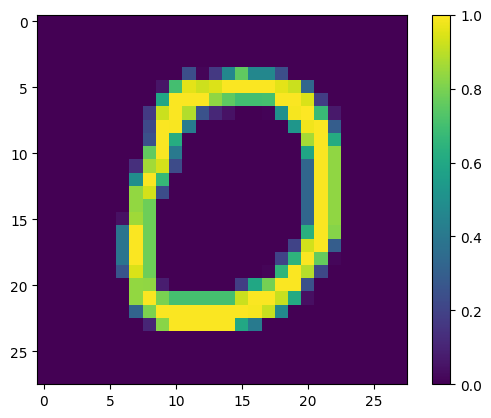

In [ ]:
plt.figure()
plt.imshow(test_images[10])
plt.colorbar()

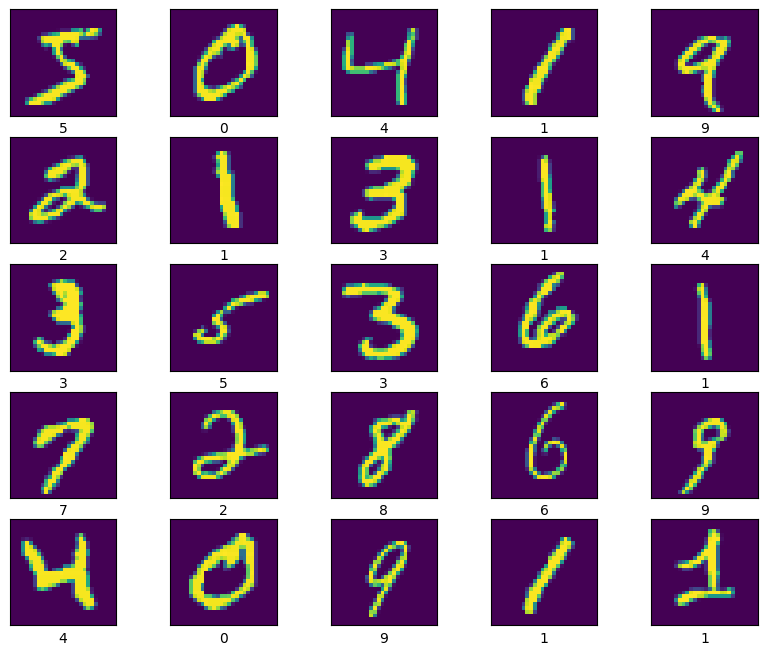

In [ ]:
plt.figure(figsize= [10,8])
for i in range(25):
  plt.subplot(5,5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(train_images[i])
  plt.xlabel(Label_name[train_labels[i]])


In [ ]:
# Bulding Model

from keras.models import Sequential
from keras.layers import Dense, Flatten

In [ ]:
Model = Sequential()
Model.add(Flatten(input_shape =(28,28)))
Model.add(Dense(128, activation= 'relu'))
Model.add(Dense(10, activation= 'softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compiling model

In [ ]:
Model.compile(optimizer='adam',loss=keras.losses.sparse_categorical_crossentropy,metrics=['accuracy'])

In [ ]:
Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model fitting

In [ ]:
History = Model.fit(train_images,train_labels, validation_data=(test_images,test_labels),epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8801 - loss: 0.4252 - val_accuracy: 0.9632 - val_loss: 0.1294
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9658 - loss: 0.1163 - val_accuracy: 0.9687 - val_loss: 0.1007
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9769 - loss: 0.0788 - val_accuracy: 0.9745 - val_loss: 0.0819
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9833 - loss: 0.0539 - val_accuracy: 0.9774 - val_loss: 0.0763
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9884 - loss: 0.0393 - val_accuracy: 0.9766 - val_loss: 0.0721
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9902 - loss: 0.0317 - val_accuracy: 0.9795 - val_loss: 0.0707
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9922 - loss: 0.0256 - val_accuracy: 0.9784 - val_loss: 0.0729
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9944 - loss: 0.0198 -

In [ ]:
Model.evaluate(test_images,test_labels,verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9770 - loss: 0.0909


[0.07513272017240524, 0.9797999858856201]

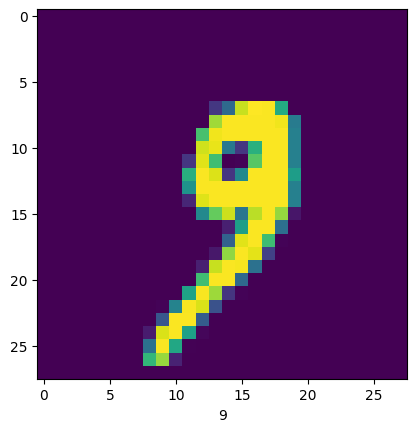

In [ ]:
plt.figure()
plt.imshow(test_images[1000])
plt.xlabel(Label_name[test_labels[1000]])
plt.show()

In [ ]:
Model.save("MNIST_Model.h5")

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
import os
os.getcwd()

'/content'

In [ ]:
load = load_model('/content/MNIST_Model.h5')

In [ ]:
load

<Sequential name=sequential, built=True>

In [ ]:
load.evaluate(test_images,test_labels,verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9770 - loss: 0.0909


[0.07513272017240524, 0.9797999858856201]